In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
data = pd.read_csv("Advertising Budget and Sales.csv")

print(data.head())

      TV Ad Budget ($)  Radio Ad Budget ($)  Newspaper Ad Budget ($)  \
0  1             230.1                 37.8                     69.2   
1  2              44.5                 39.3                     45.1   
2  3              17.2                 45.9                     69.3   
3  4             151.5                 41.3                     58.5   
4  5             180.8                 10.8                     58.4   

   Sales ($)  
0       22.1  
1       10.4  
2        9.3  
3       18.5  
4       12.9  


In [17]:
data.rename(columns={
    'TV Ad Budget ($)': 'Advertising_Spend',
    'Sales ($)': 'Sales'
}, inplace=True)

In [18]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

regions = ['North', 'South', 'East', 'West']

# Add Month column
data['Month'] = [months[i % 12] for i in range(len(data))]

# Add Region column
data['Region'] = [regions[i % 4] for i in range(len(data))]

# Create Profit column (25% of Sales)
data['Profit'] = data['Sales'] * 0.25

print(data.head())

      Advertising_Spend  Radio Ad Budget ($)  Newspaper Ad Budget ($)  Sales  \
0  1              230.1                 37.8                     69.2   22.1   
1  2               44.5                 39.3                     45.1   10.4   
2  3               17.2                 45.9                     69.3    9.3   
3  4              151.5                 41.3                     58.5   18.5   
4  5              180.8                 10.8                     58.4   12.9   

  Month Region  Profit  
0   Jan  North   5.525  
1   Feb  South   2.600  
2   Mar   East   2.325  
3   Apr   West   4.625  
4   May  North   3.225  


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0                            200 non-null    int64  
 1   Advertising_Spend        200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3   Newspaper Ad Budget ($)  200 non-null    float64
 4   Sales                    200 non-null    float64
 5   Month                    200 non-null    object 
 6   Region                   200 non-null    object 
 7   Profit                   200 non-null    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 12.6+ KB


In [20]:
print(data.describe())

                   Advertising_Spend  Radio Ad Budget ($)  \
count  200.000000         200.000000           200.000000   
mean   100.500000         147.042500            23.264000   
std     57.879185          85.854236            14.846809   
min      1.000000           0.700000             0.000000   
25%     50.750000          74.375000             9.975000   
50%    100.500000         149.750000            22.900000   
75%    150.250000         218.825000            36.525000   
max    200.000000         296.400000            49.600000   

       Newspaper Ad Budget ($)       Sales      Profit  
count               200.000000  200.000000  200.000000  
mean                 30.554000   14.022500    3.505625  
std                  21.778621    5.217457    1.304364  
min                   0.300000    1.600000    0.400000  
25%                  12.750000   10.375000    2.593750  
50%                  25.750000   12.900000    3.225000  
75%                  45.100000   17.400000    4.350

In [21]:
total_sales = data['Sales'].sum()
average_sales = data['Sales'].mean()

print("Total Sales:", total_sales)
print("Average Sales:", average_sales)

Total Sales: 2804.5
Average Sales: 14.0225


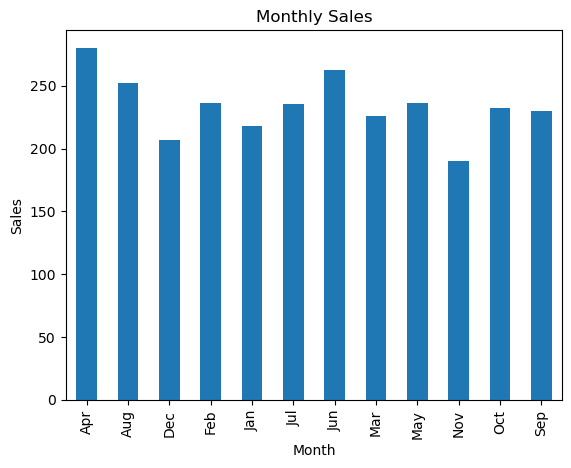

In [22]:
monthly_sales = data.groupby('Month')['Sales'].sum()

monthly_sales.plot(kind='bar')

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [23]:
region_sales = data.groupby('Region')['Sales'].mean()

print(region_sales)

Region
East     13.022
North    13.686
South    14.608
West     14.774
Name: Sales, dtype: float64


In [24]:
correlation = data.corr(numeric_only=True)

print(correlation)

                                   Advertising_Spend  Radio Ad Budget ($)  \
                         1.000000           0.017715            -0.110680   
Advertising_Spend        0.017715           1.000000             0.054809   
Radio Ad Budget ($)     -0.110680           0.054809             1.000000   
Newspaper Ad Budget ($) -0.154944           0.056648             0.354104   
Sales                   -0.051616           0.782224             0.576223   
Profit                  -0.051616           0.782224             0.576223   

                         Newspaper Ad Budget ($)     Sales    Profit  
                                       -0.154944 -0.051616 -0.051616  
Advertising_Spend                       0.056648  0.782224  0.782224  
Radio Ad Budget ($)                     0.354104  0.576223  0.576223  
Newspaper Ad Budget ($)                 1.000000  0.228299  0.228299  
Sales                                   0.228299  1.000000  1.000000  
Profit                            

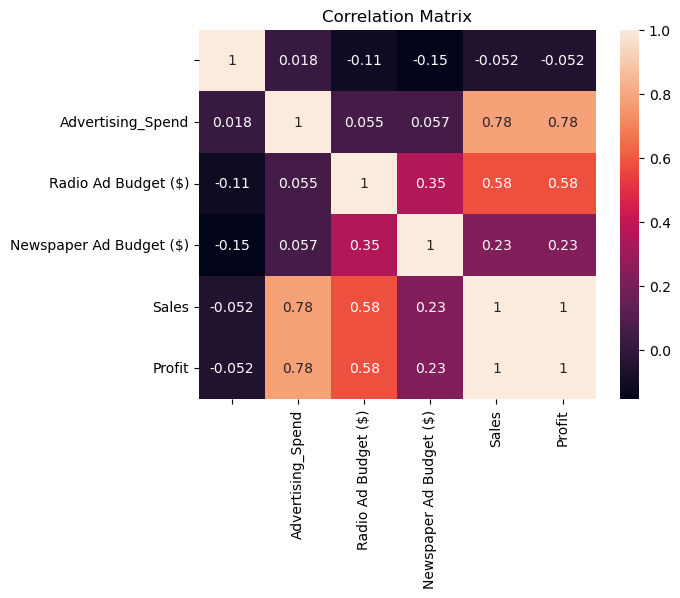

In [25]:
sns.heatmap(correlation, annot=True)

plt.title("Correlation Matrix")

plt.show()

In [27]:
low_profit = data[data['Profit'] < data['Profit'].mean()]

print(low_profit)

          Advertising_Spend  Radio Ad Budget ($)  Newspaper Ad Budget ($)  \
1      2               44.5                 39.3                     45.1   
2      3               17.2                 45.9                     69.3   
4      5              180.8                 10.8                     58.4   
5      6                8.7                 48.9                     75.0   
6      7               57.5                 32.8                     23.5   
..   ...                ...                  ...                      ...   
192  193               17.2                  4.1                     31.6   
195  196               38.2                  3.7                     13.8   
196  197               94.2                  4.9                      8.1   
197  198              177.0                  9.3                      6.4   
199  200              232.1                  8.6                      8.7   

     Sales Month Region  Profit  
1     10.4   Feb  South   2.600  
2      

In [28]:
X = data[['Advertising_Spend']]
y = data['Sales']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
from sklearn.metrics import r2_score

predictions = model.predict(X_test)

print("R2 Score:", r2_score(y_test, predictions))

R2 Score: 0.6766954295627077


In [32]:
future_sales = model.predict([[6000]])

print("Predicted Sales:", future_sales)

Predicted Sales: [286.29804066]


D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [33]:
if future_sales > average_sales:
    print("Recommendation: Increase Advertising Budget")
else:
    print("Recommendation: Optimize Cost Strategy")

Recommendation: Increase Advertising Budget
